In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

2. The Abstract Problem Interface

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

3. The Node Class

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

4. Helper Functions

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

5. Implementing the Grid Search Problem

In [5]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal

        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.

        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.

        legal_actions = []
        row, col = state
        for actions in MOVES:
            dr, dc = MOVES[actions]
            neig_cell = (row + dr, col + dc)
            if self.in_bounds(neig_cell) and self.is_free(neig_cell):
                legal_actions.append(actions)
        return legal_actions

        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        row, col = state
        dr, dc = MOVES[action]
        next_state = (row + dr, col + dc)
        return next_state
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1
        raise NotImplementedError("Complete GridProblem.action_cost")

5.1 Self-Check for GridProblem


In [6]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


6. Sample Drone Map


In [7]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

7. Visualisation Helper

In [8]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

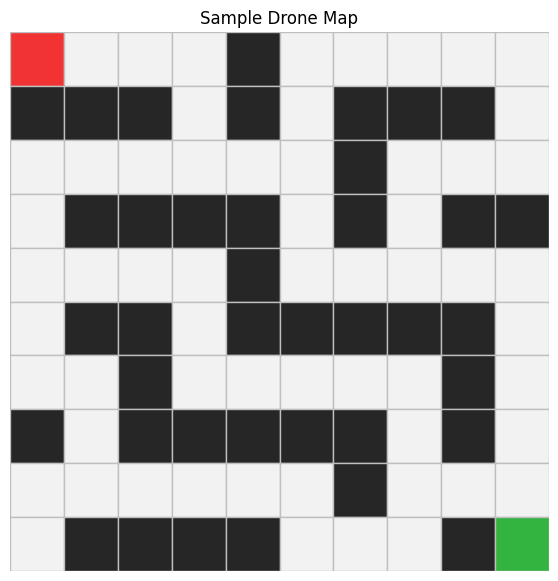

In [9]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

8. The Shared expand Method

In [10]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

9. Breadth-First Search (BFS)

In [11]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. If the initial state is the goal, return success.
        # 3. Create a deque frontier and add the initial node.
        # 4. Create a reached set and add the initial state.
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()

        node = Node(state=problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="Success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
            )

        frontier = deque([node])
        reached = {node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="Success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )

                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="Failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

        raise NotImplementedError("Complete BreadthFirstSearch.search")

10. Depth-First Search (DFS)

In [12]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        # 3. Use a Python list as the stack frontier.
        # 4. Use a reached set.
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        node = Node(state=problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="Success",
                solution=node,
                nodes_expended=0,
                max_frontier_size=1,
                reached_count=1,
            )
        frontier = [node]
        reached = {node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.pop()
            nodes_expanded = nodes_expanded + 1
            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="Success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
            max_frontier_size = max(max_frontier_size, len(frontier))
        return SearchResult(
            algorithm=algorithm,
            status="Failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

        raise NotImplementedError("Complete DepthFirstSearch.search")

11. Depth-Limited Search (DLS)

In [13]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")

        if problem.is_goal(node.state):
            return node, "success"

        elif node.depth >= limit:
            return None, "cutoff"

        metrics["nodes_expanded"] += 1
        cutoff_occurred = False

        for child in self.expand(problem, node):
            if state_is_on_path(node, child.state):
                continue

            metrics["max_stack_size"] = max(
                metrics["max_stack_size"],
                current_stack_size + 1,
            )

            result, status = self._recursive_dls(
                problem=problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=current_stack_size + 1,
            )

            if status == "success":
                return result, "success"

            elif status == "cutoff":
                cutoff_occurred = True

        if cutoff_occurred:
            return None, "cutoff"
        else:
            return None, "failure"

        raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")

12. Iterative Deepening Search (IDS)

In [14]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)

        iteration_log = []
        total_nodes_expanded = 0
        max_stack_size = 0

        dls = DepthLimitedSearch()

        for limit in range(max_depth + 1):
            result = dls.search(problem, limit=limit)

            iteration_log.append(
                {
                    "limit": limit,
                    "status": result.status,
                }
            )

            total_nodes_expanded += result.nodes_expanded

            max_stack_size = max(
                max_stack_size,
                result.max_frontier_size,
            )

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    reached_count=0,
                    iterations=iteration_log,
                )

            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    reached_count=0,
                    iterations=iteration_log,
                )

        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            reached_count=0,
            iterations=iteration_log,
        )

        raise NotImplementedError("Complete IterativeDeepeningSearch.search")


13. Run the Algorithms on the Sample Map

In [15]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Success,NaN,18.0,18.0,50,5,52
1,DFS,Success,NaN,18.0,18.0,18,4,21
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,NaN,18.0,18.0,356,19,0


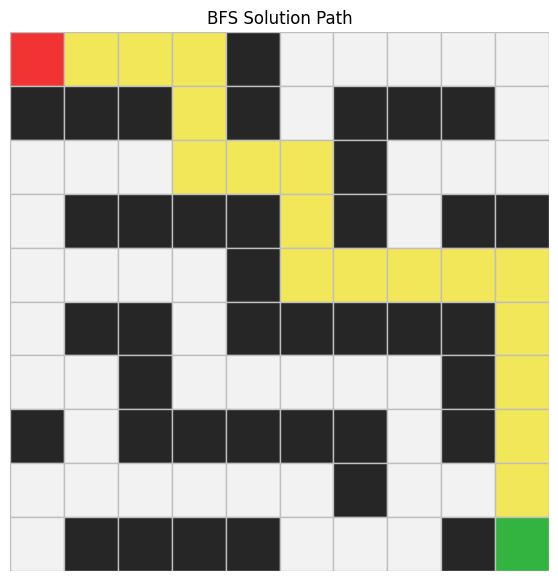

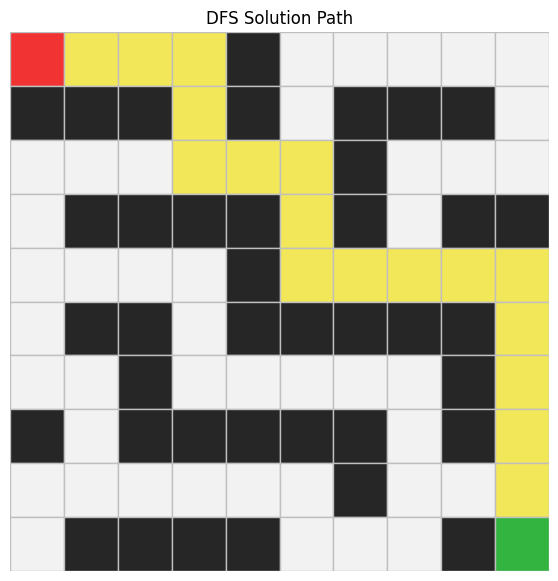

In [16]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

14. Create Your Own Maps

In [17]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (9, 9)

# Example after completing:
# custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
# custom_results_1 = [
#     bfs.search(custom_problem_1),
#     dfs.search(custom_problem_1),
#     dls.search(custom_problem_1, limit=20),
#     ids.search(custom_problem_1, max_depth=40),
# ]
# show_results(custom_results_1)

In [18]:
print(len(custom_grid_1))

10


In [19]:
print(len(custom_grid_1))
print(custom_grid_1[0])
print(len(custom_grid_1[0]))

10
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
10


In [20]:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

print("Created successfully")

Created successfully


In [21]:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Success,NaN,18,18,54,5,55
1,DFS,Success,NaN,40,40,46,7,52
2,DLS,success,20.0,18,18,48,21,0
3,IDS,success,NaN,18,18,463,19,0


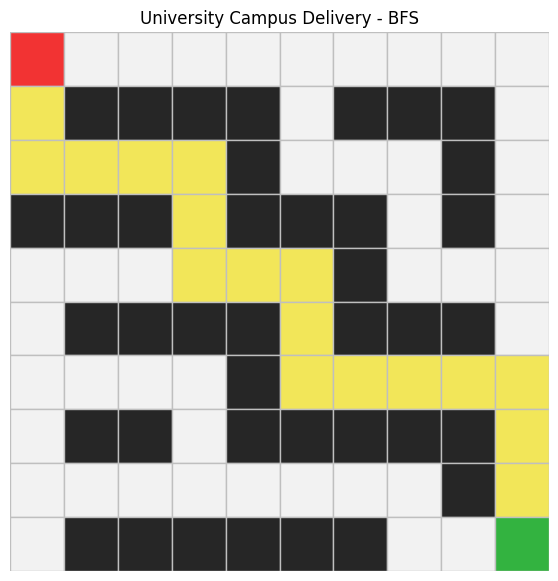

In [22]:
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[0].path,
    title="University Campus Delivery - BFS",
)

Interpretation: The University Campus Delivery map contains multiple alternative routes between the start and goal locations. BFS found a solution with a depth and cost of 18, demonstrating its ability to identify the shortest path in a uniform-cost environment. DFS also reached the goal but produced a longer path with a depth and cost of 40 because it explored deeper branches before locating the destination. IDS and DLS found the same optimal solution as BFS, although IDS expanded significantly more nodes due to repeatedly executing depth-limited searches.

In [23]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (9, 9)

# Example after completing:
# custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
# custom_results_2 = [
#     bfs.search(custom_problem_2),
#     dfs.search(custom_problem_2),
#     dls.search(custom_problem_2, limit=20),
#     ids.search(custom_problem_2, max_depth=40),
# ]
# show_results(custom_results_2)

In [24]:
print(custom_grid_2)

[[0, 0, 0, 1, 0, 0, 0, 0, 0, 0], [1, 1, 0, 1, 0, 1, 1, 1, 1, 0], [0, 0, 0, 1, 0, 0, 0, 0, 1, 0], [0, 1, 1, 1, 1, 1, 1, 0, 1, 0], [0, 0, 0, 0, 0, 0, 1, 0, 1, 0], [1, 1, 1, 1, 1, 0, 1, 0, 1, 0], [0, 0, 0, 0, 1, 0, 1, 0, 1, 0], [0, 1, 1, 0, 1, 0, 1, 0, 1, 0], [0, 1, 0, 0, 0, 0, 1, 0, 0, 0], [0, 1, 1, 1, 1, 1, 1, 1, 0, 0]]


In [25]:
print(len(custom_grid_2))
print(len(custom_grid_2[0]))

10
10


In [26]:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

In [27]:
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]

show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Failure,NaN,None,None,29,2,29
1,DFS,Failure,NaN,None,None,29,2,29
2,DLS,cutoff,20.0,None,None,20,21,0
3,IDS,failure,NaN,None,None,414,28,0


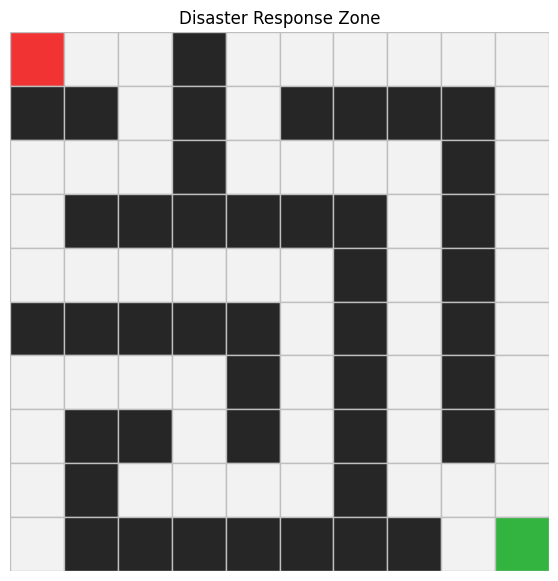

In [28]:
plot_path(custom_grid_2, custom_start_2, custom_goal_2, title="Disaster Response Zone")

Interpretation: This map represents a disaster response area with many blocked roads. None of the algorithms were able to reach the goal because there was no valid path between the start and goal locations. BFS, DFS, and IDS failed, while DLS reached its depth limit and returned a cutoff. This shows how search algorithms behave when a solution does not exist.


15. Reflection Questions

15.1 Problem Formulation
- What is a state in this lab?
A state represents the drone's current position on the grid.

- What is an action?
An action is a movement the drone can make: UP, DOWN, LEFT, or RIGHT.

- What does the result function do?
The result function returns the next state after applying an action to the current state.

- Why is it useful to separate the problem definition from the search algorithm?
It makes the code more flexible. We can use the same search algorithms on different problems without changing the algorithm itself.

15.2 BFS

- Why does BFS use a FIFO queue?
BFS explores states in the order they are discovered. The first state added is the first one explored.

- Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
Because BFS explores all states at one depth level before moving to the next level.

- What role does the reached set play in BFS?
The reached set prevents the algorithm from visiting the same state multiple times

15.3 DFS

- Why does DFS use a stack?
DFS always explores the most recently discovered state first, which follows the Last In First Out principle.

- Is DFS guaranteed to find the shortest path? Explain.
No. DFS may find a longer path because it explores deep branches before considering other options.

- Under what conditions can DFS use less memory than BFS?
DFS can use less memory when the search space is large because it only stores one path at a time.

- Under what conditions can DFS perform badly?
DFS performs badly when it follows long dead ends or explores deep branches that do not lead to the goal.

15.4 DLS

- What happens when the depth limit is too small?
The algorithm may not reach the goal even if a solution exists.

- What is the meaning of "cutoff"?
A cutoff means the search stopped because it reached the depth limit.

- How is DLS different from ordinary DFS?
DLS has a maximum depth limit, while DFS can continue searching deeper.

- Why do we use path-cycle checking in DLS?
It prevents the search from revisiting states already on th current path and getting stuck in loops.


15.5 IDS

- Why does IDS repeat DLS with increasing limits?
It gradually searches deeper levels until a solution is found.

- Why can IDS be complete even though DLS with a small limit is not?
Because IDS keeps increasing the limit until it reaches the depth of the solution.

- Why does IDS use less memory than BFS?
IDS uses DLS internally, so it only stores a small number of nodes at a time.

- What is the cost of repeatedly searching from the root?
Some nodes are explored multiple times, which increases the total number of node expansions.

15.6 Real-World Drone Context

- In a real drone application, what might make one route safer or more practical than another?
Factors such as obstacles, weather conditions, restricted areas, battery life, and terrain can affect the safety and practicality of a route.

- Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
I would choose BFS because it finds the shortest path when all movess have the same cost.

- Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.
I would choose DLS because it allows me to set a maximum search depth.

- What limitations does this grid model have compared with real drone navigation?
The grid model is very simple. Real drones must deal with weather, battery limits, changing environments, different flying speeds, and three-dimensional movement.